In [1]:
pip install SpeechRecognition

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 42.6 MB/s eta 0:00:00


## **Speech Recognition**

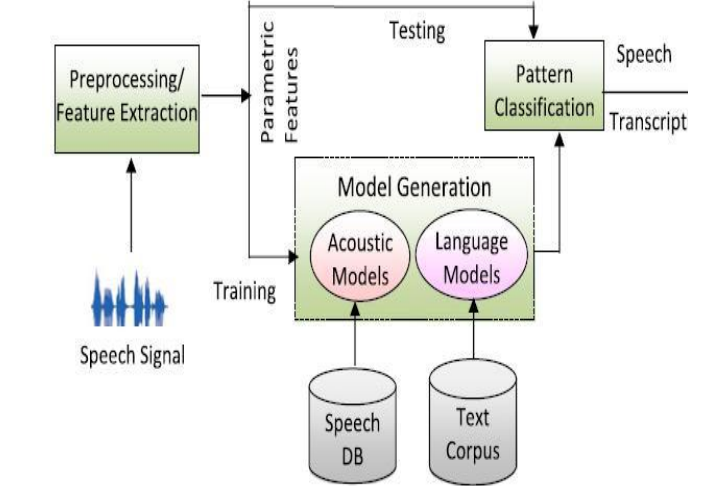

In [2]:
#https://www.voiptroubleshooter.com/open_speech/american

import speech_recognition as sr
a = sr.AudioFile("/content/OSR_us_000_0014_8k.wav")
with a as source:
    a = sr.Recognizer().record(source)
print(sr.Recognizer().recognize_google(a))


a King rule the state in the early days the ship was torn apart on the sharp Reef sickness kept him home the third week the wide Road shimmered in the hot sun the lazy cow lay in the choreographed lift the square Stone over the fence the Rope will bind the seven books at once hop over the fence and plunging friendly gang left the drug store mesh wire keeps chips inside


In [3]:
# Install deps (works in Colab/Notebook)
!pip -q install SpeechRecognition gradio

import gradio as gr
import speech_recognition as sr

def transcribe(audio_path, language):
    """
    audio_path: filepath from gr.Audio (type='filepath')
    language: BCP-47 code like 'en-US', 'zh-SG', etc.
    """
    if not audio_path:
        return "Please record or upload an audio file."

    r = sr.Recognizer()
    try:
        # Optional: light noise adjustment for better results
        with sr.AudioFile(audio_path) as source:
            r.adjust_for_ambient_noise(source, duration=0.2)
            audio = r.record(source)  # whole file

        text = r.recognize_google(audio, language=language)
        return text
    except sr.UnknownValueError:
        return "Couldn't understand the audio."
    except sr.RequestError as e:
        return f"API request error: {e}"
    except Exception as e:
        return f"Error: {e}"

LANGS = {
    "English (US)": "en-US",
    "English (UK)": "en-GB",
    "Chinese (Mandarin, Simplified)": "zh-CN",
    "Chinese (Mandarin, Singapore)": "zh-SG",
    "Malay": "ms-MY",
    "Tamil": "ta-IN",
    "Hindi": "hi-IN",
}

with gr.Blocks(title="Speech to Text (SpeechRecognition + Google)") as demo:
    gr.Markdown("### 🎤 Upload or record audio, then click **Transcribe**")
    with gr.Row():
        audio = gr.Audio(sources=["microphone", "upload"], type="filepath", label="Audio")
        lang = gr.Dropdown(choices=list(LANGS.values()),
                           value="en-US",
                           label="Language (BCP-47)")
    out = gr.Textbox(label="Transcript", lines=6)
    btn = gr.Button("Transcribe")
    btn.click(transcribe, inputs=[audio, lang], outputs=out)

demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e8b40e86aae2dcc269.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
